# BAQ DBSCAN

In [ ]:
import sys
import os
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from pandas import Timedelta
from sklearn import metrics
import datetime

In [ ]:
df = pd.read_csv('../csv/preprocessed_data.csv')
df_norm = pd.read_csv('../csv/preprocessed_data_norm.csv')
df_ips = pd.read_csv('../csv/preprocessed_data_ips.csv')

In [112]:
df = df.set_index(['TestKey'])
df

,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,...,Q62_A1_ips,Q62_A2_ips,Q62_A3_ips,Q62_A4_ips,Q62_A5_ips,Q63_A1_ips,Q63_A2_ips,Q63_A3_ips,Q63_A4_ips,Q63_A5_ips
TestKey,,,,,,,,,,,,,,,,,,,,,
183642,0.0,0.0,0.0,0.0,0.0,2.0,3.0,5.0,1.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
183643,0.0,0.0,0.0,0.0,0.0,4.0,5.0,1.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
183644,0.0,0.0,0.0,0.0,0.0,4.0,5.0,2.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
183645,0.0,0.0,0.0,0.0,0.0,4.0,3.0,1.0,2.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
183646,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255092,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255098,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,5.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255101,0.0,0.0,0.0,0.0,0.0,3.0,5.0,4.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:

df_for_pca = df

pca10 = PCA(n_components=10)


In [114]:
df_pca10 = pd.DataFrame(pca10.fit_transform(df_for_pca),index=df.index)
df_pca10

,0,1,2,3,4,5,6,7,8,9
TestKey,,,,,,,,,,
183642,-18.788819,0.820538,1.282804,-2.994540,3.078581,0.727180,-0.959121,-1.425434,-3.783496,0.453684
183643,-18.760569,0.798503,1.185116,-3.113745,3.120693,0.759219,-0.411983,-1.219433,-3.894304,0.383883
183644,-18.756529,0.792931,1.159148,-3.142390,3.134676,0.634817,-0.684621,-1.278201,-3.928153,0.388028
183645,-18.764535,0.796307,1.219628,-3.071391,3.102322,0.731215,-0.791720,-1.364559,-3.880821,0.440846
183646,-18.795927,0.834245,1.304047,-2.974283,3.069796,0.901684,-0.399481,-1.264887,-3.737452,0.416048
...,...,...,...,...,...,...,...,...,...,...
255092,-16.924039,0.075305,-2.461435,-1.140722,-2.596180,-1.371008,1.595077,1.542281,10.377668,-0.888683
255098,-17.313929,0.280151,-1.404982,-0.746923,-3.033762,0.210441,-0.536640,1.716132,-8.387137,-1.018837
255101,-15.912597,-0.372794,-5.577690,-4.759469,0.404722,-0.349445,0.147110,0.889919,5.077800,-0.729467


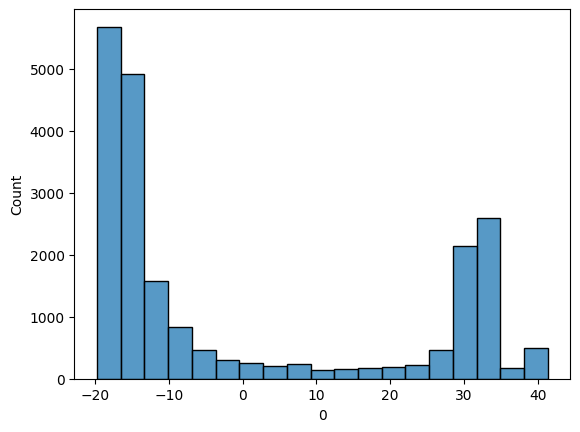

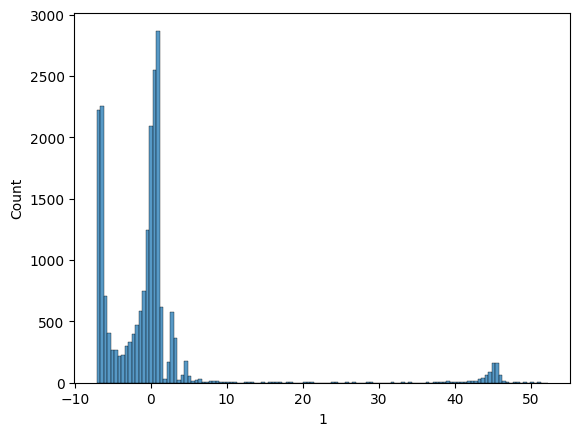

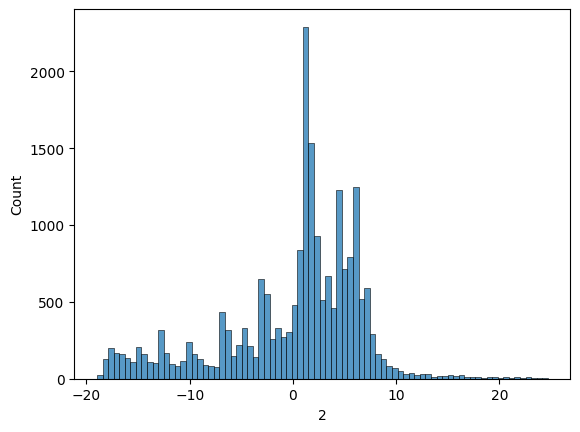

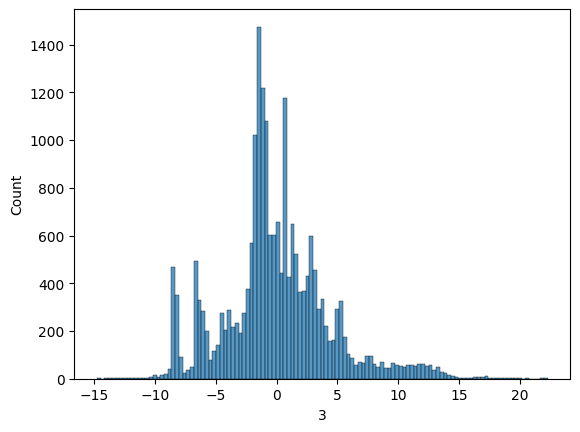

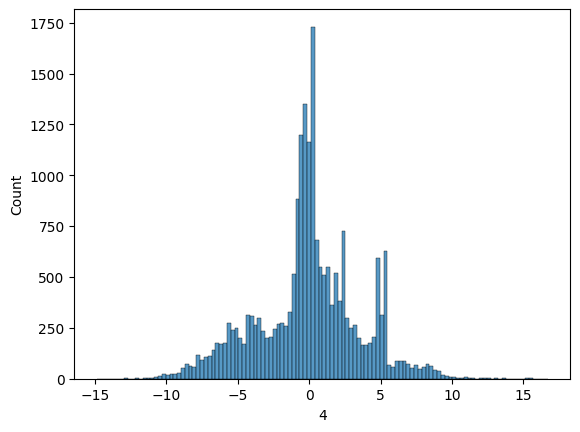

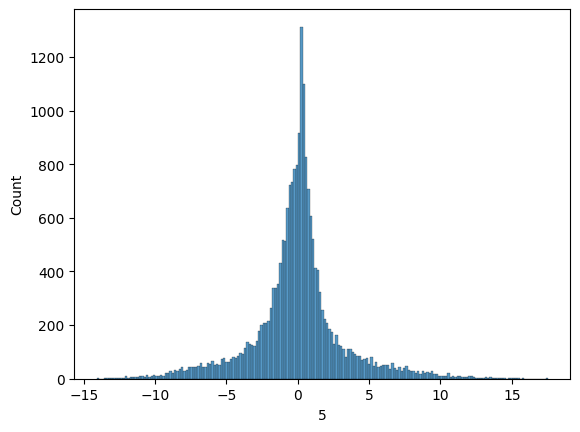

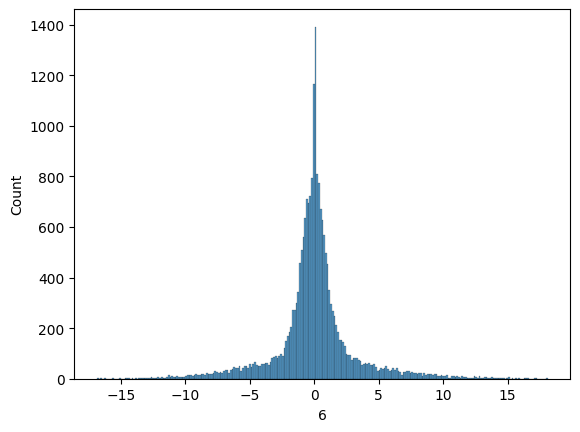

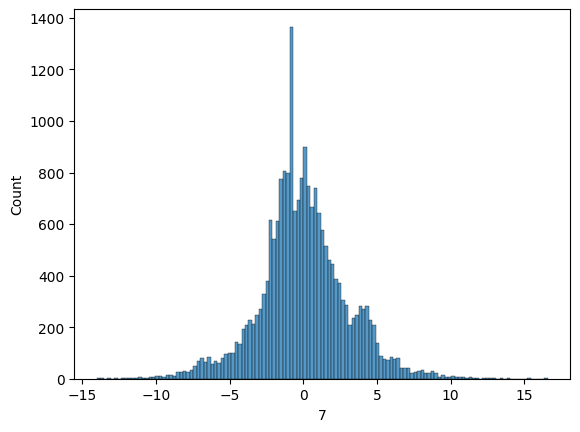

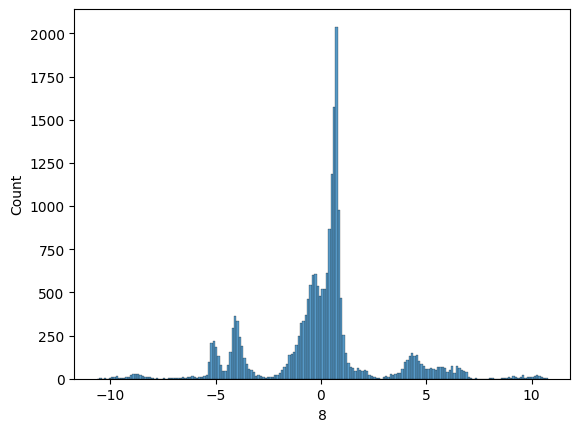

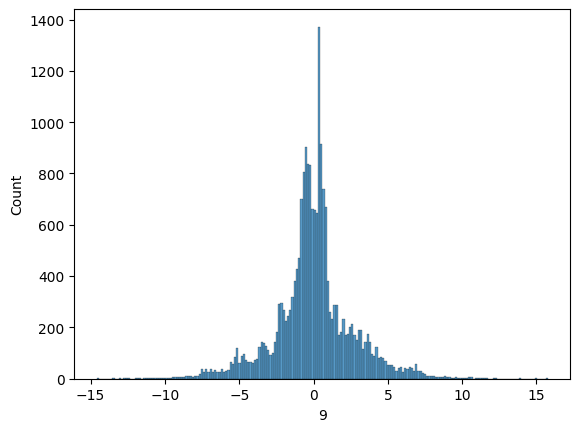

In [115]:
for i in range(10):
  sns.histplot(df_pca10[i])
  plt.show()

In [116]:
sc = StandardScaler()
df_pca10_scaled = pd.DataFrame(sc.fit_transform(df_pca10),index=df.index,columns=df_pca10.columns)
df_pca10_scaled

,0,1,2,3,4,5,6,7,8,9
TestKey,,,,,,,,,,
183642,-0.877545,0.088761,0.188361,-0.672080,0.855109,0.225416,-0.309387,-0.476235,-1.326807,0.170785
183643,-0.876226,0.086377,0.174017,-0.698834,0.866807,0.235347,-0.132895,-0.407410,-1.365666,0.144510
183644,-0.876037,0.085774,0.170204,-0.705263,0.870691,0.196784,-0.220840,-0.427044,-1.377536,0.146070
183645,-0.876411,0.086140,0.179085,-0.689328,0.861704,0.226667,-0.255388,-0.455896,-1.360937,0.165953
183646,-0.877877,0.090243,0.191481,-0.667534,0.852669,0.279510,-0.128862,-0.422596,-1.310661,0.156618
...,...,...,...,...,...,...,...,...,...,...
255092,-0.790449,0.008146,-0.361426,-0.256018,-0.721117,-0.424994,0.514529,0.515273,3.639270,-0.334537
255098,-0.808659,0.030305,-0.206301,-0.167636,-0.842660,0.065234,-0.173106,0.573356,-2.941225,-0.383532
255101,-0.743209,-0.040327,-0.819004,-1.068192,0.112416,-0.108323,0.047454,0.297320,1.780697,-0.274601


In [117]:
df_pca10_scaled.drop_duplicates(inplace=True)
df_pca10_scaled

,0,1,2,3,4,5,6,7,8,9
TestKey,,,,,,,,,,
183642,-0.877545,0.088761,0.188361,-0.672080,0.855109,0.225416,-0.309387,-0.476235,-1.326807,0.170785
183643,-0.876226,0.086377,0.174017,-0.698834,0.866807,0.235347,-0.132895,-0.407410,-1.365666,0.144510
183644,-0.876037,0.085774,0.170204,-0.705263,0.870691,0.196784,-0.220840,-0.427044,-1.377536,0.146070
183645,-0.876411,0.086140,0.179085,-0.689328,0.861704,0.226667,-0.255388,-0.455896,-1.360937,0.165953
183646,-0.877877,0.090243,0.191481,-0.667534,0.852669,0.279510,-0.128862,-0.422596,-1.310661,0.156618
...,...,...,...,...,...,...,...,...,...,...
255092,-0.790449,0.008146,-0.361426,-0.256018,-0.721117,-0.424994,0.514529,0.515273,3.639270,-0.334537
255098,-0.808659,0.030305,-0.206301,-0.167636,-0.842660,0.065234,-0.173106,0.573356,-2.941225,-0.383532
255101,-0.743209,-0.040327,-0.819004,-1.068192,0.112416,-0.108323,0.047454,0.297320,1.780697,-0.274601


In [118]:
dbscan = DBSCAN(eps=0.05, min_samples=5,n_jobs=-1)
dbscan.fit(df_pca10_scaled)

DBSCAN(eps=0.05, n_jobs=-1)

In [119]:
values, counts = np.unique(dbscan.labels_,return_counts=True)
counts[1:].sum()

1361

In [120]:
values

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62], dtype=int64)

In [121]:
print(metrics.silhouette_score(df_pca10_scaled, dbscan.labels_))


-0.4564761779181518


In [122]:
def GridSearchDBScan(min_samples_values,eps_values):
  min_samples_values = min_samples_values
  eps_values = eps_values
  results = []
  for min_samples in min_samples_values:
      for eps in eps_values:
        try:   
            startTime = datetime.datetime.now()
            print(f"Trying min_samples {min_samples} and eps {eps}")
            # Create and fit DBSCAN model
            dbscan = DBSCAN(min_samples=min_samples, eps=eps)
            dbscan.fit(df_pca10_scaled)
            labels = dbscan.labels_

            if len(set(labels)) > 1:
                silhouette_avg = metrics.silhouette_score(df_pca10_scaled, labels)
            else:
                silhouette_avg = -1
            
            duration = Timedelta(datetime.datetime.now()-startTime)
            print(f"Silhouette ({min_samples,eps}): {silhouette_avg}")
            print(f"Duration: {duration}")
            results.append({
                'min_samples': min_samples,
                'eps': eps,
                'silhouette_score': silhouette_avg,
                'num_clusters': len(set(labels)) - (1 if -1 in labels else 0),
                'num_noise': list(labels).count(-1)
            })
        except Exception as error:
           print(error)
  return results

# results = GridSearchDBScan(min_samples_values=[3, 5, 10, 20, 50],eps_values=[0.01,0.05,0.5,2,5])
# The best result set uses min_samples_values = 10 and eps = 2
best_dbscan = DBSCAN(min_samples=10,eps=2)


In [123]:
best_dbscan.fit(df_pca10_scaled)
values, counts = np.unique(best_dbscan.labels_,return_counts=True)
counts[1:].sum()

20691

In [124]:
counts

array([  503, 20016,   675], dtype=int64)

In [125]:
values

array([-1,  0,  1], dtype=int64)

I get the first instance considered as an anomaly to doublecheck whether the correct indices are maintained when joining

In [126]:
best_dbscan.labels_.argmin(-1)

134

Out of 21194 tests, 503 are considered anomalies. There are 2 clusters in which all other instances belong. Next step is to join the original dataframe to the created labels

In [127]:
labels = pd.DataFrame(best_dbscan.labels_,index=df.index, columns=['label'])
labels

,label
TestKey,
183642,0
183643,0
183644,0
183645,0
183646,0
...,...
255092,0
255098,0
255101,0


In [128]:
labels[133:136]

,label
TestKey,
202039,0
202040,-1
202044,-1


As expected, the 134th row (which has key 202040 indeed has a label of -1)

In [129]:
dbscan_anom = pd.concat([df,labels],axis=1)
dbscan_anom = dbscan_anom[dbscan_anom.label==-1]

In [130]:
dbscan_anom

,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,...,Q62_A2_ips,Q62_A3_ips,Q62_A4_ips,Q62_A5_ips,Q63_A1_ips,Q63_A2_ips,Q63_A3_ips,Q63_A4_ips,Q63_A5_ips,label
TestKey,,,,,,,,,,,,,,,,,,,,,
202040,0.0,0.0,0.0,0.0,0.0,5.0,2.0,3.0,4.0,1.0,...,3.0,4.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,-1
202044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1
202137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,2.0,1.0,5.0,4.0,3.0,2.0,1.0,-1
202165,5.0,2.0,4.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,...,4.0,2.0,3.0,5.0,4.0,3.0,5.0,2.0,1.0,-1
202943,5.0,2.0,4.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254620,0.0,0.0,0.0,0.0,0.0,5.0,4.0,2.0,3.0,1.0,...,1.0,2.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,-1
254681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,5.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,-1
254871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,5.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,-1


In [131]:
df_pca2 = pd.DataFrame(df_pca10_scaled.iloc[:,0:2], index=df.index)
df_pca2.columns=['x','y']
df_pca2

,x,y
TestKey,,
183642,-0.877545,0.088761
183643,-0.876226,0.086377
183644,-0.876037,0.085774
183645,-0.876411,0.086140
183646,-0.877877,0.090243
...,...,...
255092,-0.790449,0.008146
255098,-0.808659,0.030305
255101,-0.743209,-0.040327


In [132]:
anomalies2d = df_pca2.loc[dbscan_anom.index]

In [133]:
anomalies2d

,x,y
TestKey,,
202040,0.304493,-0.260473
202044,0.054410,-0.337675
202137,-0.062385,2.202362
202165,1.124621,4.204478
202943,-0.145354,1.921786
...,...,...
254620,0.917288,-0.535556
254681,1.058502,-0.383445
254871,0.345159,-0.327682


<Axes: xlabel='x', ylabel='y'>

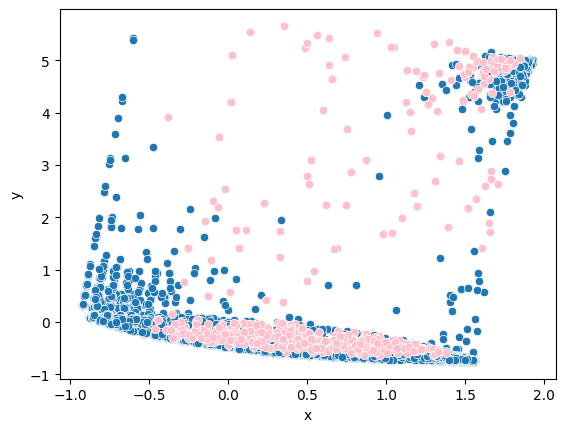

In [134]:
sns.scatterplot(df_pca2,x=df_pca2.x,y=df_pca2.y)
sns.scatterplot(anomalies2d,x=anomalies2d.x,y=anomalies2d.y,color="pink")

In [135]:
labels['is_anomaly'] = labels[['label']].map(lambda label : 1 if label==-1 else 0)

In [136]:
labels[130:140]

,label,is_anomaly
TestKey,,
202035,0,0
202036,0,0
202038,1,0
202039,0,0
202040,-1,1
202044,-1,1
202046,0,0
202050,0,0
202051,0,0


In [137]:
labels.drop(columns=['label'],inplace=True)

In [138]:
os.chdir('..')
csv_path = os.path.join("csv")
os.chdir(csv_path)
labels.to_csv('dbscan_anomalies.csv')